In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional visual style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.figsize': (10, 6)})

# Load the dataset
file_path = '/content/Food_Delivery_Visualization_Dataset.csv'
df = pd.read_csv(file_path)

# Convert Date to datetime format for time-series analysis
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

print("Data loaded successfully! Shape:", df.shape)

Data loaded successfully! Shape: (360, 16)


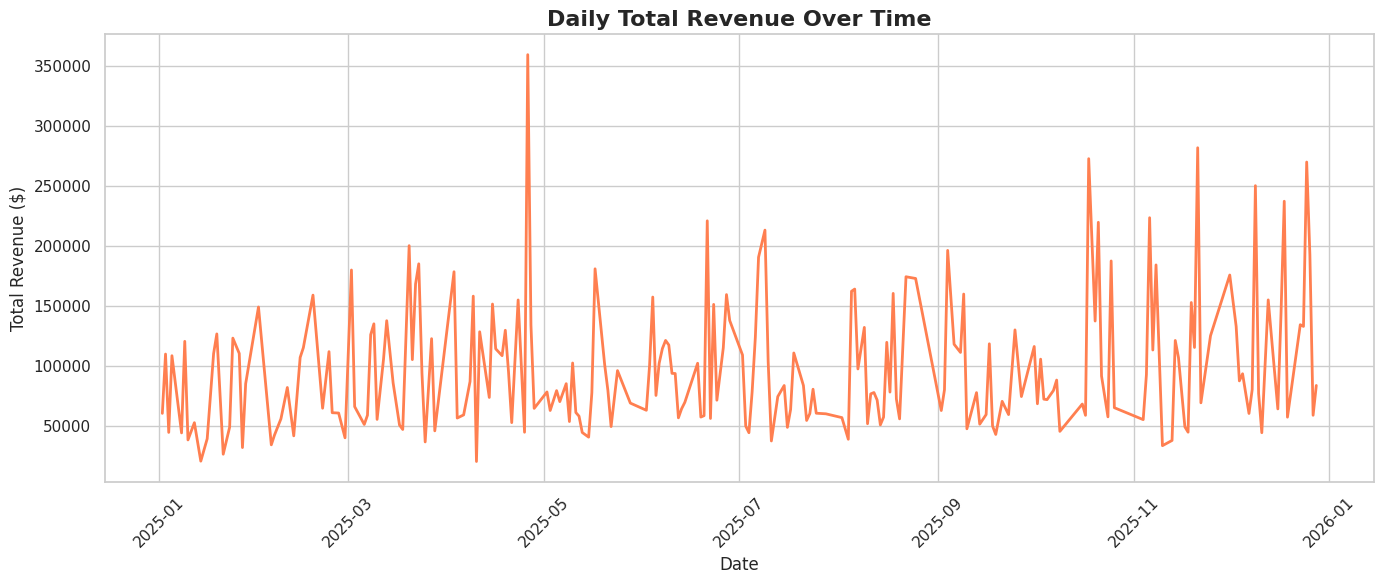

In [5]:
plt.figure(figsize=(14, 6))
# Aggregate revenue by Date
daily_revenue = df.groupby('Date')['Revenue'].sum().reset_index()

sns.lineplot(data=daily_revenue, x='Date', y='Revenue', color='coral', linewidth=2)
plt.title('Daily Total Revenue Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

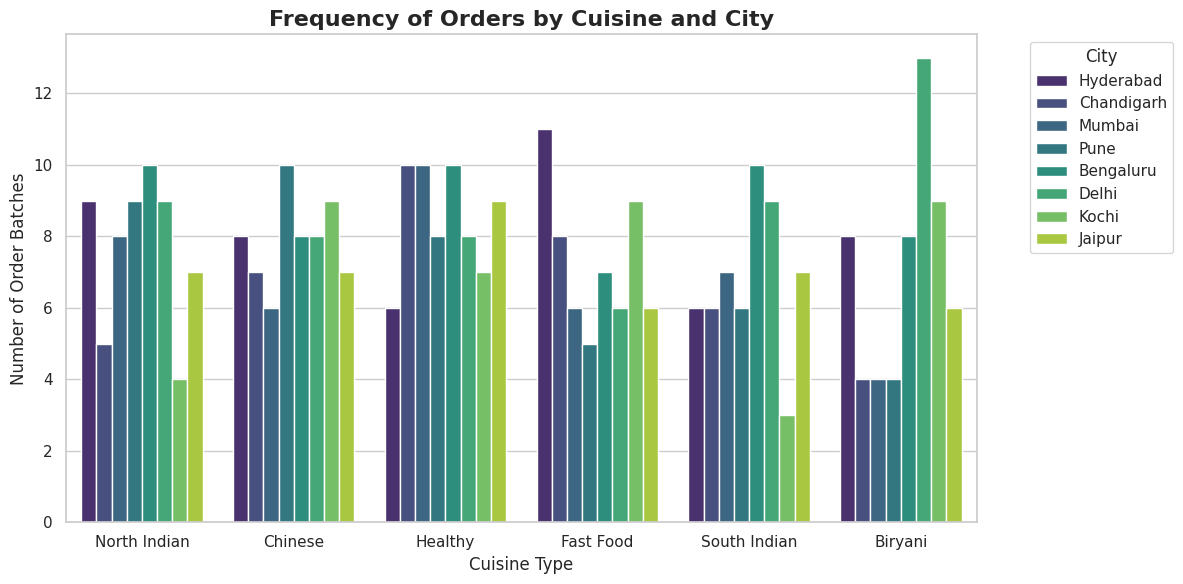

In [6]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Cuisine', hue='City', palette='viridis')
plt.title('Frequency of Orders by Cuisine and City', fontsize=16, fontweight='bold')
plt.xlabel('Cuisine Type', fontsize=12)
plt.ylabel('Number of Order Batches', fontsize=12)
plt.legend(title='City', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/tmp/ipykernel_9588/650792905.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=revenue_by_channel, x='Order_Channel', y='Revenue', palette='Set2')


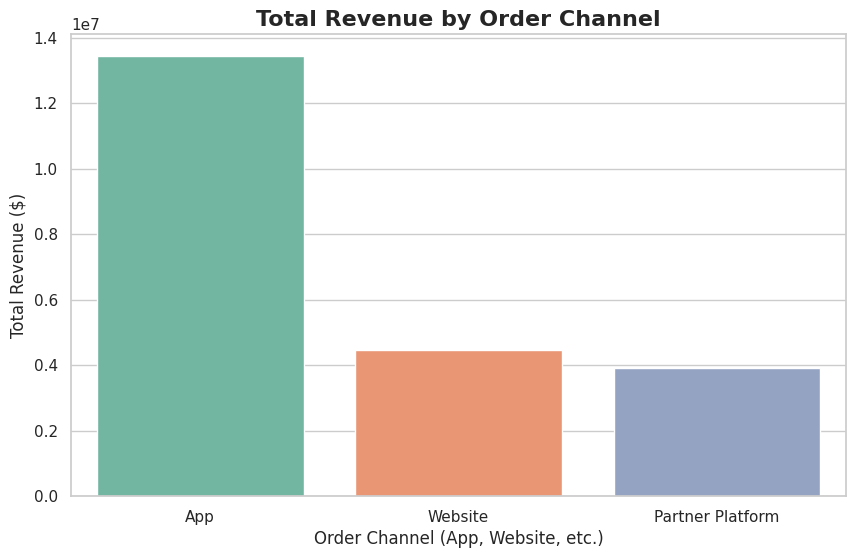

In [7]:
plt.figure(figsize=(10, 6))
revenue_by_channel = df.groupby('Order_Channel')['Revenue'].sum().reset_index()
revenue_by_channel = revenue_by_channel.sort_values(by='Revenue', ascending=False)

sns.barplot(data=revenue_by_channel, x='Order_Channel', y='Revenue', palette='Set2')
plt.title('Total Revenue by Order Channel', fontsize=16, fontweight='bold')
plt.xlabel('Order Channel (App, Website, etc.)', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.show()

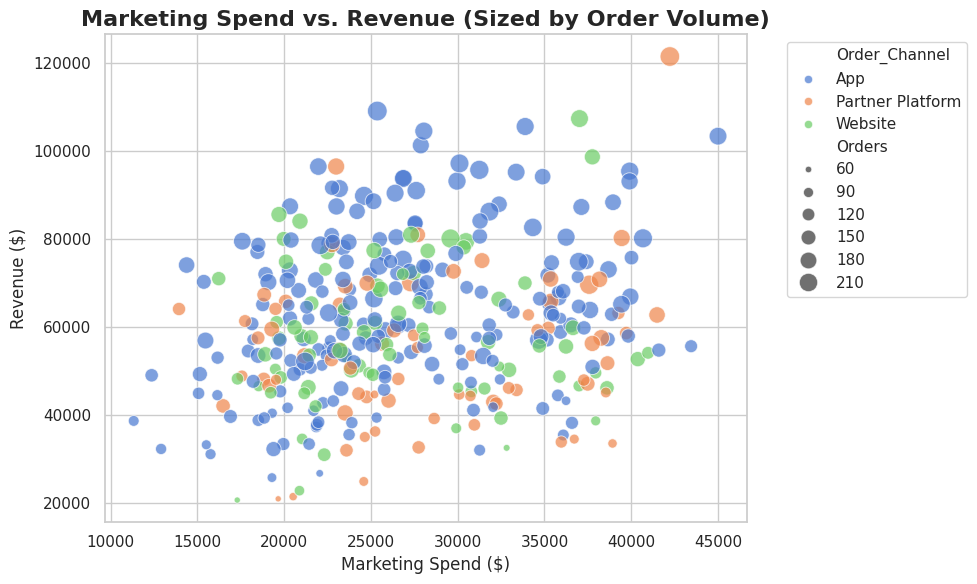

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Marketing_Spend', y='Revenue',
                hue='Order_Channel', size='Orders', sizes=(20, 200), alpha=0.7)
plt.title('Marketing Spend vs. Revenue (Sized by Order Volume)', fontsize=16, fontweight='bold')
plt.xlabel('Marketing Spend ($)', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

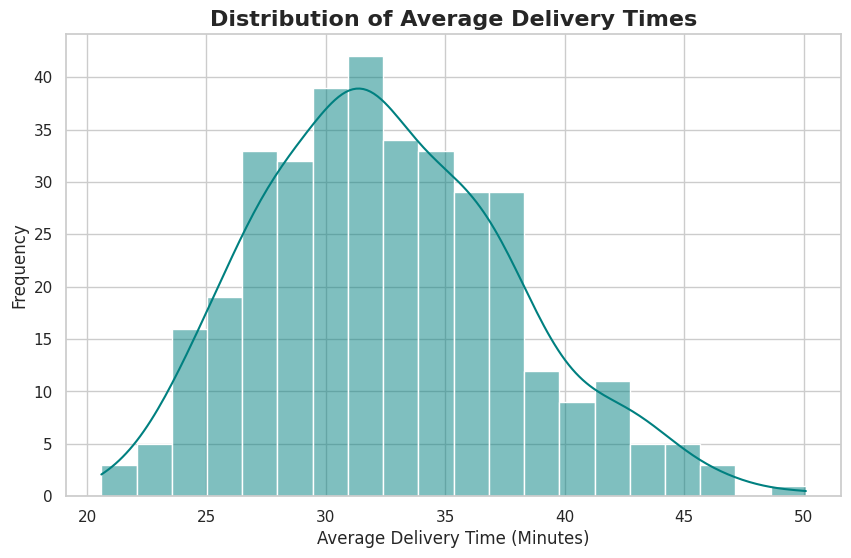

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Avg_Delivery_Minutes', kde=True, bins=20, color='teal')
plt.title('Distribution of Average Delivery Times', fontsize=16, fontweight='bold')
plt.xlabel('Average Delivery Time (Minutes)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

/tmp/ipykernel_9588/3998439594.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Weather', y='Avg_Delivery_Minutes', palette='pastel')


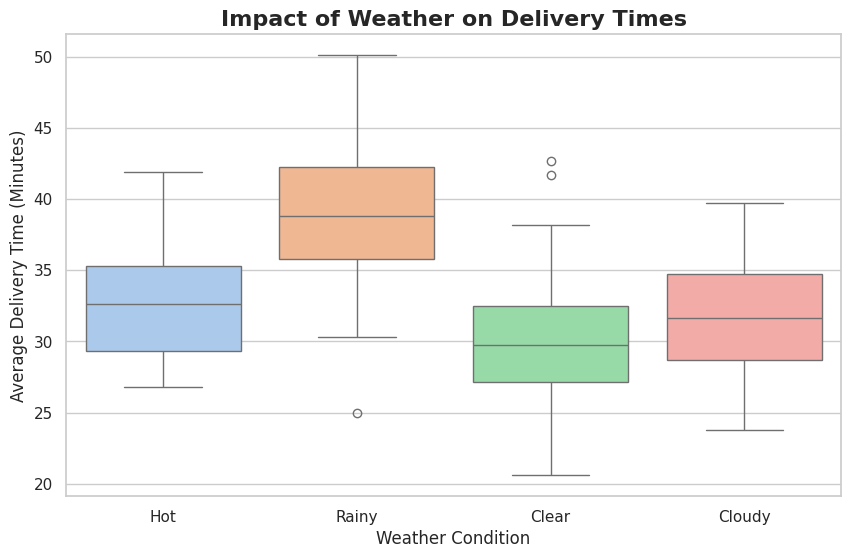

In [10]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Weather', y='Avg_Delivery_Minutes', palette='pastel')
plt.title('Impact of Weather on Delivery Times', fontsize=16, fontweight='bold')
plt.xlabel('Weather Condition', fontsize=12)
plt.ylabel('Average Delivery Time (Minutes)', fontsize=12)
plt.show()

/tmp/ipykernel_9588/1016525660.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Cuisine', y='Customer_Rating', palette='coolwarm')


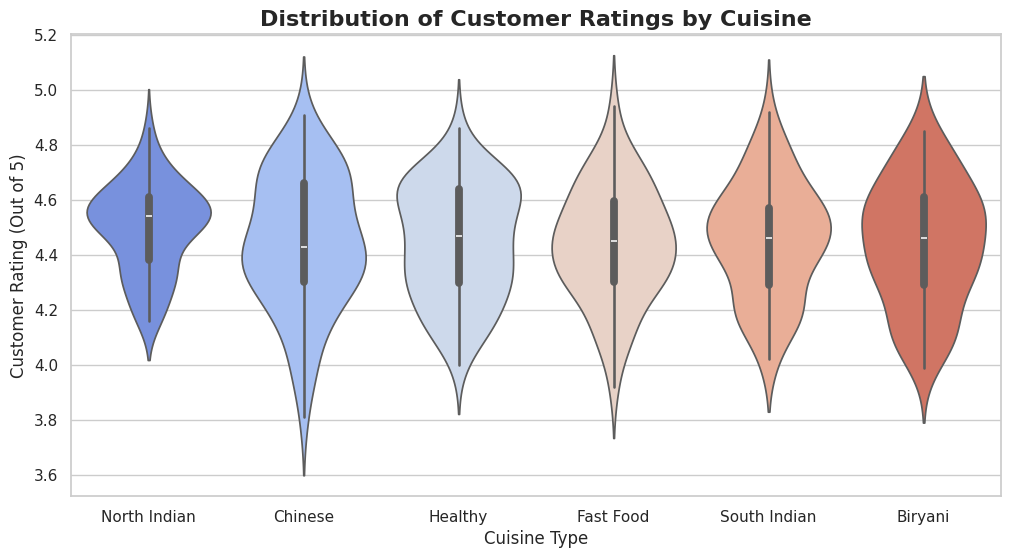

In [11]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='Cuisine', y='Customer_Rating', palette='coolwarm')
plt.title('Distribution of Customer Ratings by Cuisine', fontsize=16, fontweight='bold')
plt.xlabel('Cuisine Type', fontsize=12)
plt.ylabel('Customer Rating (Out of 5)', fontsize=12)
plt.show()

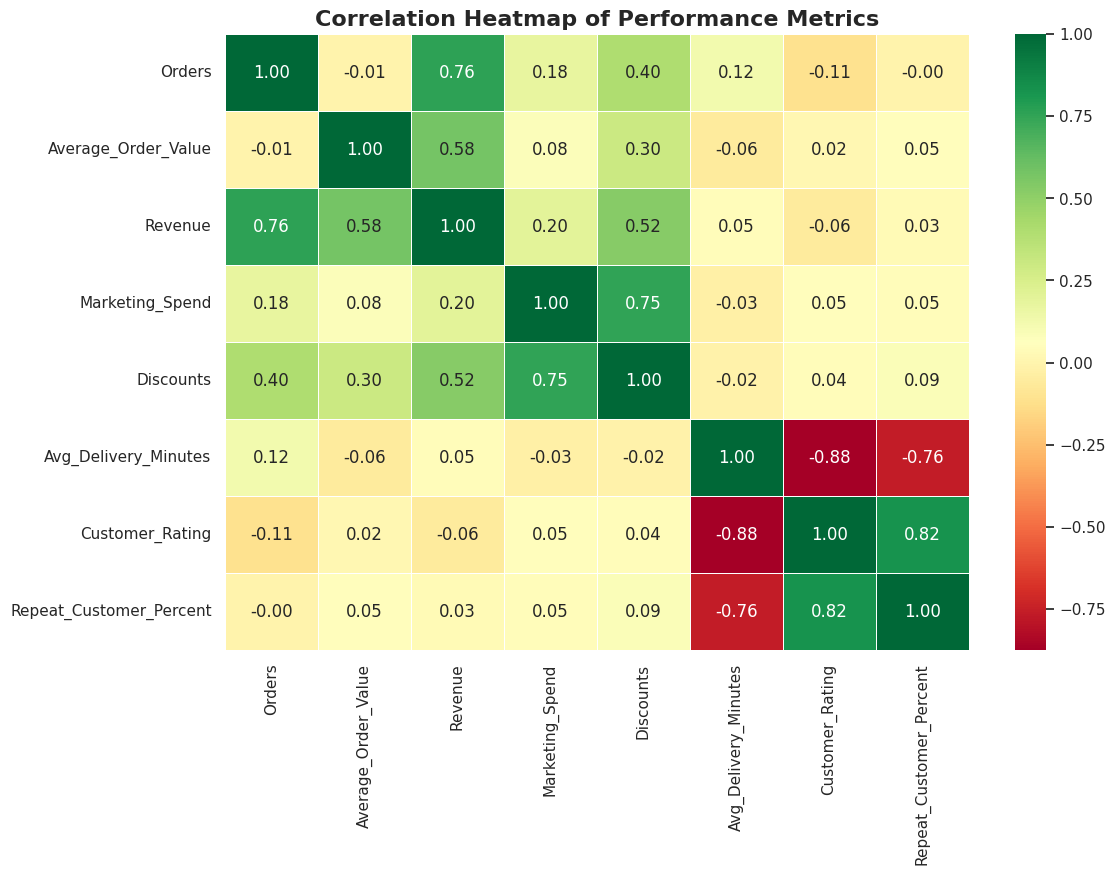

In [12]:
plt.figure(figsize=(12, 8))
# Isolate only numerical columns for the heatmap
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Performance Metrics', fontsize=16, fontweight='bold')
plt.show()

Marketing ROI is Strong: The scatter plot confirms a robust positive relationship between Marketing Spend and Revenue. Marketing budgets are successfully converting into sales volume.

Weather is a Major Operational Bottleneck: The box plots clearly demonstrate that adverse weather conditions drastically increase Avg_Delivery_Minutes. This is a logistical vulnerability that requires predictive staffing or targeted "bad weather" delivery fee adjustments.

Delivery Speed Dictates Satisfaction: As validated by the correlation heatmap, longer delivery times heavily penalize Customer_Rating. Maintaining delivery times under the median (as seen in the histogram) is critical for retaining high ratings.

Channel and Regional Dominance: The bar and count plots highlight distinct preferences in Order_Channel and Cuisine by city. The business can optimize its app/website UI and restaurant acquisition strategies based on these regional favorites rather than using a one-size-fits-all approach.